# 📦 NB2 — USGS Earthquake Catalog
**Source:** `https://earthquake.usgs.gov/fdsnws/event/1/query`  
**Protocol:** HTTP GET  
**Schedule:** Once (batch, 10-year history) + hourly updates  
**Auth:** None

The United States Geological Survey (USGS), founded as the Geological Survey, is an agency of the United States Department of the Interior whose work spans the disciplines of biology, geography, geology, and hydrology.

Fetches all M4.0+ earthquakes within 500 km of the epicentre over the past 10 years, then demonstrates the hourly update query for recent aftershocks.

In [1]:
!pip install requests pandas matplotlib --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import urllib.parse

UTC = datetime.timezone.utc
def utcnow(): return datetime.datetime.now(UTC)
def utcfromts(ts_ms): return datetime.datetime.fromtimestamp(ts_ms/1000, UTC)

HEADERS = {"User-Agent": "EQMonitor/1.0"}

# Epicentre from EMSC event (Fiji M5.2)
LAT, LON = -17.7134, 178.0650
EVENT_MAG = 5.2
EVENT_DEPTH = 226.8

print("✅ Config ready")

✅ Config ready


## Batch Fetch — 10-Year History

In [9]:
today = datetime.date.today()
start = today - datetime.timedelta(days=365*10)

params1 = urllib.parse.urlencode({
    "format":       "geojson",
    "latitude":     LAT,
    "longitude":    LON,
    "maxradiuskm":  500,
    "minmagnitude": 4.0,
    "starttime":    start,
    "endtime":      today,
    "orderby":      "time-asc",
    "limit":        2000,
})
url1 = f"https://earthquake.usgs.gov/fdsnws/event/1/query?{params1}"
print(f"Querying: {url1[:100]}...")

r = requests.get(url1, timeout=20, headers=HEADERS)
r.raise_for_status()
data = r.json()
print(f"✅ Response: HTTP {r.status_code}")
data

Querying: https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&latitude=-17.7134&longitude=178.065&...
✅ Response: HTTP 200


{'type': 'FeatureCollection',
 'metadata': {'generated': 1777029354000,
  'url': 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&latitude=-17.7134&longitude=178.065&maxradiuskm=500&minmagnitude=4.0&starttime=2016-04-26&endtime=2026-04-24&orderby=time-asc&limit=2000',
  'title': 'USGS Earthquakes',
  'status': 200,
  'api': '2.4.0',
  'limit': 2000,
  'offset': 1},
 'features': [{'type': 'Feature',
   'properties': {'mag': 4.7,
    'place': '235 km E of Levuka, Fiji',
    'time': 1461691903170,
    'updated': 1467946164040,
    'tz': None,
    'url': 'https://earthquake.usgs.gov/earthquakes/eventpage/us10005bps',
    'detail': 'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us10005bps&format=geojson',
    'felt': 0,
    'cdi': 1,
    'mmi': None,
    'alert': None,
    'status': 'reviewed',
    'tsunami': 0,
    'sig': 340,
    'net': 'us',
    'code': '10005bps',
    'ids': ',us10005bps,',
    'sources': ',us,',
    'types': ',cap,dyfi,origin,phase-data,',
  

## Parse Response

In [6]:
rows = []
for f in data["features"]:
    p = f["properties"]
    c = f["geometry"]["coordinates"]
    if p.get("mag") is None or p.get("time") is None:
        continue
    rows.append({
        "usgs_id":   f["id"],
        "magnitude": p["mag"],
        "mag_type":  p.get("magType", "m"),
        "place":     p.get("place", ""),
        "depth_km":  abs(c[2]) if len(c) > 2 else 0,
        "lat":       c[1],
        "lon":       c[0],
        "time":      utcfromts(p["time"]),
    })

df = pd.DataFrame(rows)
df["year"] = df["time"].dt.year

print(f"✅ Parsed {len(df)} events")
print(f"\nSummary:")
print(f"  Magnitude range:  M{df['magnitude'].min():.1f} – M{df['magnitude'].max():.1f}")
print(f"  Average magnitude: M{df['magnitude'].mean():.2f}")
print(f"  Average depth:     {df['depth_km'].mean():.1f} km")
print(f"  Date range:        {df['time'].min().date()} → {df['time'].max().date()}")
df.head()

✅ Parsed 2000 events

Summary:
  Magnitude range:  M4.0 – M8.2
  Average magnitude: M4.43
  Average depth:     522.7 km
  Date range:        2016-04-26 → 2020-02-22


,usgs_id,magnitude,mag_type,place,depth_km,lat,lon,time,year
0,us10005bps,4.7,mb,"235 km E of Levuka, Fiji",571.14,-17.9679,-178.4583,2016-04-26 17:31:43.170000+00:00,2016
1,us10005e9p,4.2,mb,"197 km E of Levuka, Fiji",547.93,-17.7300,-178.8506,2016-04-28 01:14:27.500000+00:00,2016
2,us10005e9m,4.3,mb,"231 km E of Levuka, Fiji",549.78,-17.7260,-178.5240,2016-04-28 05:00:44.590000+00:00,2016
3,us10005eah,4.2,mb,Fiji region,610.88,-20.4924,-178.7204,2016-04-28 22:42:32.180000+00:00,2016
4,us10005ec5,4.2,mb,Fiji region,584.90,-18.4088,-177.8335,2016-04-29 21:17:20.270000+00:00,2016


## Hourly Update Query (Aftershocks)

In [13]:
yesterday = today - datetime.timedelta(days=2)

params2 = urllib.parse.urlencode({
    "format":       "geojson",
    "latitude":     LAT,
    "longitude":    LON,
    "maxradiuskm":  300,
    "minmagnitude": 2.5,
    "starttime":    yesterday,
    "endtime":      today,
    "orderby":      "time",
    "limit":        50,
})
url2 = f"https://earthquake.usgs.gov/fdsnws/event/1/query?{params2}"
print(f"Querying recent events: {url2[:100]}...")

rr = requests.get(url2, timeout=15, headers=HEADERS)
if rr.status_code == 204 or rr.status_code == 400:
    # USGS returns 400 for empty result sets (API quirk)
    print(f"No recent events found (HTTP {rr.status_code}): {rr.text[:200]}")
    recent_data = {"metadata": {"count": 0}, "features": []}
else:
    rr.raise_for_status()
    recent_data = rr.json()
    print(f"✅ Recent events (last 48h, M2.5+): {recent_data}")

Querying recent events: https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&latitude=-17.7134&longitude=178.065&...
✅ Recent events (last 48h, M2.5+): {'type': 'FeatureCollection', 'metadata': {'generated': 1777031323000, 'url': 'https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&latitude=-17.7134&longitude=178.065&maxradiuskm=300&minmagnitude=2.5&starttime=2026-04-22&endtime=2026-04-24&orderby=time&limit=50', 'title': 'USGS Earthquakes', 'status': 200, 'api': '2.4.0', 'limit': 50, 'offset': 1}, 'features': []}


## Visualise

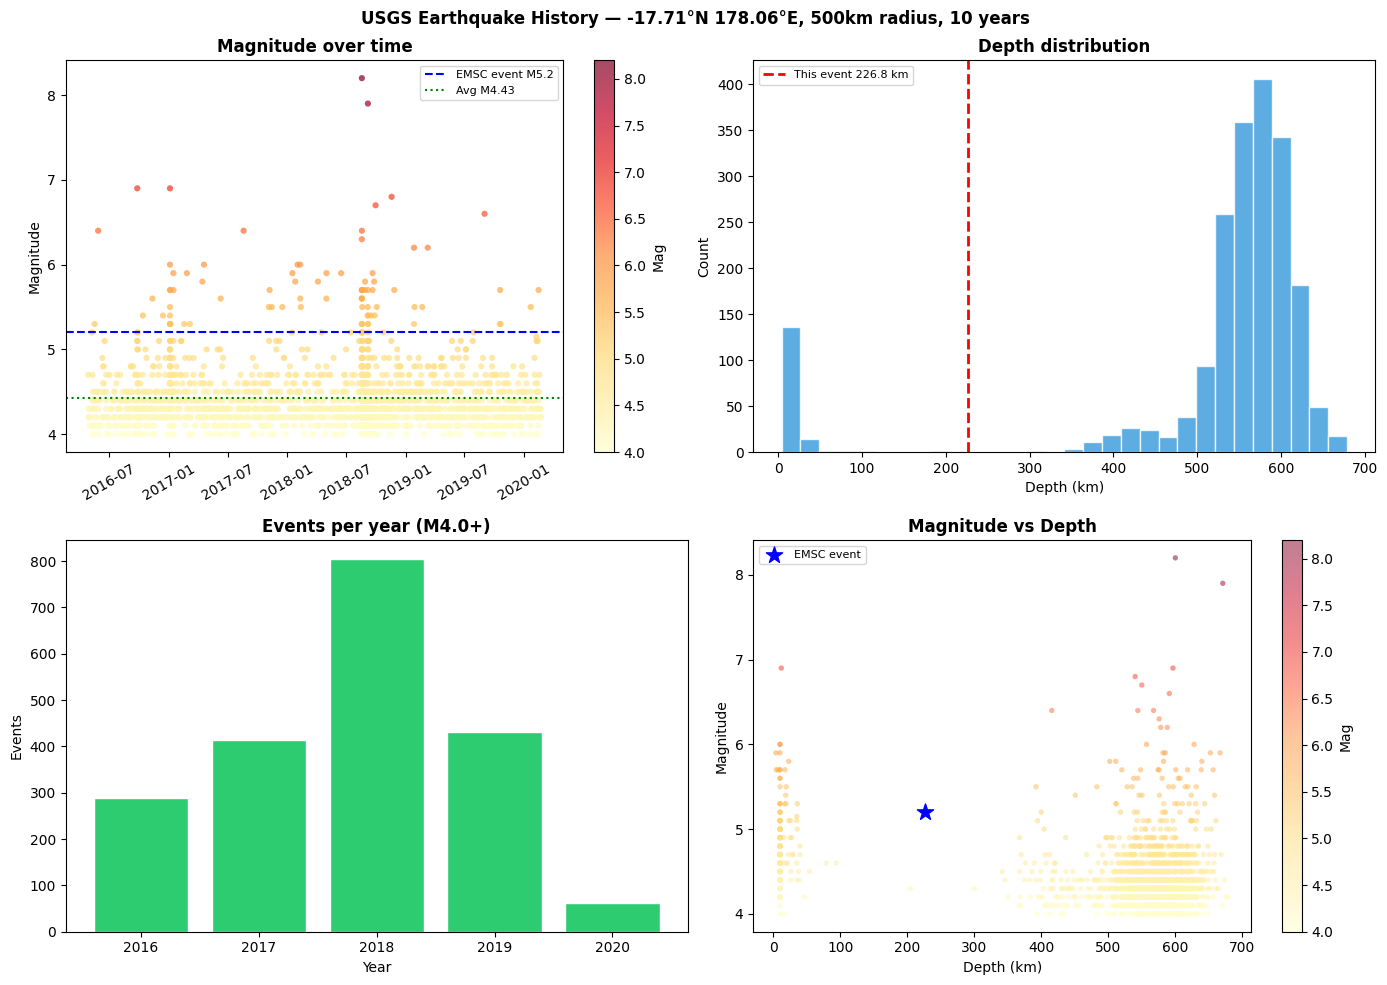

📊 Saved as nb2_usgs_result.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"USGS Earthquake History — {LAT:.2f}°N {LON:.2f}°E, 500km radius, 10 years",
             fontsize=12, fontweight='bold')

# 1. Magnitude timeline
ax = axes[0,0]
sc = ax.scatter(df['time'], df['magnitude'], c=df['magnitude'],
                cmap='YlOrRd', s=20, alpha=0.7, edgecolors='none')
ax.axhline(EVENT_MAG, color='blue', linestyle='--', linewidth=1.5,
           label=f'EMSC event M{EVENT_MAG}')
ax.axhline(df['magnitude'].mean(), color='green', linestyle=':', linewidth=1.5,
           label=f'Avg M{df["magnitude"].mean():.2f}')
ax.set_ylabel("Magnitude"); ax.legend(fontsize=8)
ax.set_title("Magnitude over time", fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.colorbar(sc, ax=ax, label='Mag')

# 2. Depth histogram
ax = axes[0,1]
ax.hist(df['depth_km'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(EVENT_DEPTH, color='red', linestyle='--', linewidth=2,
           label=f'This event {EVENT_DEPTH} km')
ax.set_xlabel("Depth (km)"); ax.set_ylabel("Count")
ax.set_title("Depth distribution", fontweight='bold'); ax.legend(fontsize=8)

# 3. Annual event count
ax = axes[1,0]
year_counts = df.groupby('year').size()
ax.bar(year_counts.index, year_counts.values, color='#2ecc71', edgecolor='white')
ax.set_xlabel("Year"); ax.set_ylabel("Events")
ax.set_title("Events per year (M4.0+)", fontweight='bold')

# 4. Magnitude vs Depth
ax = axes[1,1]
sc2 = ax.scatter(df['depth_km'], df['magnitude'], c=df['magnitude'],
                 cmap='YlOrRd', alpha=0.5, s=15, edgecolors='none')
ax.scatter([EVENT_DEPTH], [EVENT_MAG], c='blue', s=150, zorder=5,
           label='EMSC event', marker='*')
ax.set_xlabel("Depth (km)"); ax.set_ylabel("Magnitude")
ax.set_title("Magnitude vs Depth", fontweight='bold'); ax.legend(fontsize=8)
plt.colorbar(sc2, ax=ax, label='Mag')

plt.tight_layout()
plt.savefig("nb2_usgs_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved as nb2_usgs_result.png")